# pHMC

In [1]:
import time
from dataclasses import dataclass

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.diagnostics import effective_sample_size
from numpyro.infer import HMC, MCMC, Predictive

import dynestyx as dsx
from dynestyx import (
    DiscreteTimeSimulator,
    DynamicalModel,
    Filter,
    LinearGaussianObservation,
    LinearGaussianStateEvolution,
)
from dynestyx.inference.filters import (
    KFConfig,
    MarginalPFConfig,
    PFConfig,
    PFResamplingConfig,
)

import jax.numpy as jnp

import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, DynamicalModel, LinearGaussianStateEvolution


jax.config.update("jax_enable_x64", True)


In [2]:
def model(sigma_h=None, alpha=None, rho=None, obs_times=None, obs_values=None):
    inv_sigma_h_obs = None if sigma_h is None else 1 / sigma_h**2
    inv_sigma_h = numpyro.sample(
        "inv_sigma_h", dist.Gamma(1e-1, 1e-1), obs=inv_sigma_h_obs
    )
    sigma_h = jnp.sqrt(1.0 / inv_sigma_h)

    rho = numpyro.sample("rho", dist.Uniform(-0.999, 0.999), obs=rho)
    alpha = numpyro.sample("alpha", dist.Normal(0.0, 10.0), obs=alpha)

    dynamics_model = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            jnp.zeros(1),
            jnp.array([[sigma_h**2 / (1.0 - rho**2)]]),  # variance, not sd
        ),
        state_evolution=LinearGaussianStateEvolution(
            A=jnp.array([[rho]]), cov=jnp.array([[sigma_h**2]])
        ),
        observation_model=lambda x, u, t: dist.Poisson(
            jnp.exp(x[0] + alpha)
        ),  # exp(h + alpha)
        state_dim=1,
        control_dim=0,
        observation_dim=1,
    )

    dsx.sample(
        "f",
        dynamics_model,
        obs_times=obs_times,
        obs_values=obs_values,
    )


In [3]:
true_rho = dist.Uniform(-0.999, 0.999).sample(jr.PRNGKey(0))
true_inv_sigma_h = dist.Gamma(1, 1).sample(jr.PRNGKey(1))
true_alpha = 2

true_rho, true_inv_sigma_h, true_alpha


(Array(-0.16292269, dtype=float64), Array(1.31830802, dtype=float64), 2)

In [4]:
obs_times = jnp.arange(0.0, 100.0, 1.0) 

def make_data():
    predictive = Predictive(
        model,
        params={
            "rho": jnp.array(true_rho),
            "inv_sigma_h": jnp.array(true_inv_sigma_h),
            "alpha": jnp.array(true_alpha),
        },
        num_samples=1,
        exclude_deterministic=False,
    )
    with DiscreteTimeSimulator():
        pred = predictive(rng_key=jr.PRNGKey(0), obs_times=obs_times)

    obs_values = pred["observations"][0]
    return obs_times, obs_values, pred


obs_times, obs_values, pred = make_data()


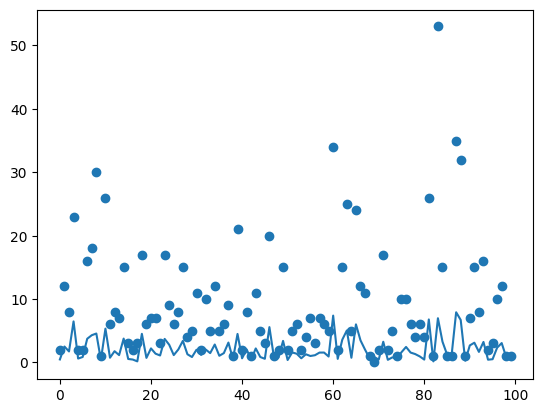

In [5]:
import matplotlib.pyplot as plt

plt.plot(jnp.exp(pred["states"][0] + 0.5))
plt.scatter(obs_times, obs_values)
plt.show()


In [6]:
from dynestyx.inference.filter_configs import (
    MarginalPFConfig,
    PFResamplingConfig,
    EKFConfig,
)


def data_conditioned_model(obs_times, obs_values):
    filter_config = MarginalPFConfig(n_particles=200, resampling_method=PFResamplingConfig(base_method="systematic", differential_method="stop_gradient"))
    # filter_config = EKFConfig()
    # filter_config = PFConfig(n_particles=1_000, resampling_method=PFResamplingConfig(base_method="systematic", differential_method="stop_gradient"))
    with Filter(filter_config=filter_config):
        model(obs_times=obs_times, obs_values=obs_values)


In [7]:
predictive = Predictive(
    data_conditioned_model,
    params={
        "rho": jnp.array(true_rho),
        "inv_sigma_h": jnp.array(true_inv_sigma_h),
        "alpha": jnp.array(true_alpha),
    },
    num_samples=1,
    exclude_deterministic=False,
)

filter_outputs = predictive(
    rng_key=jr.PRNGKey(0), obs_times=obs_times, obs_values=obs_values
)


/Users/danwaxman/Documents/dynestyx/dynestyx/inference/filters.py:296: UserWarning: PFJax stop-gradient mode requires resampling at every step for its correction term to be valid. Overriding ess_threshold_ratio from 0.7 to 1.0.
  run_pfjax_discrete(


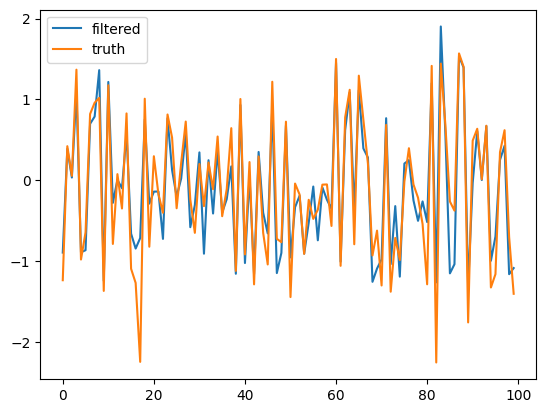

In [8]:
plt.plot(filter_outputs["f_filtered_states_mean"].squeeze(), label="filtered")
plt.plot(pred["states"][0], label="truth")
plt.legend()
plt.show()


In [9]:
from numpyro.infer.util import initialize_model
from numpyro.infer.initialization import init_to_sample

rng_key = jr.PRNGKey(0)
rng_key, init_key = jax.random.split(rng_key)
init_params, potential_fn_gen, postprocess_fn, *_ = initialize_model(
    init_key,
    data_conditioned_model,
    model_args=(obs_times, obs_values),
    dynamic_args=True,
    init_strategy=init_to_sample,
)

logdensity_fn = lambda position: -potential_fn_gen(obs_times, obs_values)(position)
initial_position = init_params.z


In [10]:
import blackjax
from tqdm import tqdm
from jax import tree_util

hmc = blackjax.hmc(logdensity_fn, 1e-2, jnp.eye(len(initial_position)), 10)
state = hmc.init(initial_position)


def inference_loop(rng_key, kernel, initial_state, num_samples):

    @jax.jit
    def one_step(state, rng_key):
        state, info = kernel(rng_key, state)
        return state, info

    keys = jax.random.split(rng_key, num_samples)

    state = initial_state

    states = []
    acceptance_rate = []
    is_divergent = []
    num_integration_steps = []

    for key in tqdm(keys):
        state, info = one_step(state, key)

        states.append(state)
        acceptance_rate.append(info.acceptance_rate)
        is_divergent.append(info.is_divergent)
        num_integration_steps.append(info.num_integration_steps)

    # stack to match scan outputs
    states = tree_util.tree_map(lambda *xs: jnp.stack(xs), *states)

    acceptance_rate = jnp.stack(acceptance_rate)
    is_divergent = jnp.stack(is_divergent)
    num_integration_steps = jnp.stack(num_integration_steps)

    return states, (
        acceptance_rate,
        is_divergent,
        num_integration_steps,
    )


In [11]:
num_sample = 1_000
rng_key, sample_key = jax.random.split(rng_key)
states, infos = inference_loop(sample_key, hmc.step, state, num_sample)
_ = states.position["rho"].block_until_ready()


100%|██████████| 1000/1000 [05:48<00:00,  2.87it/s]


In [12]:
rng_key, sample_key = jax.random.split(rng_key)
states2, infos2 = inference_loop(sample_key, hmc.step, state, num_sample)
_ = states2.position["rho"].block_until_ready()

100%|██████████| 1000/1000 [05:53<00:00,  2.83it/s]


In [13]:
import arviz as az

# positions_stacked = {
#     k: jnp.stack([states.position[k][100:], states2.position[k][100:]])
#     for k in ["alpha", "inv_sigma_h", "rho"]
# }

def _postprocess_single(i):
    full = postprocess_fn(obs_times, obs_values)(
        {
            "alpha": states.position["alpha"][i],
            "inv_sigma_h": states.position["inv_sigma_h"][i],
            "rho": states.position["rho"][i],
        }
    )
    return {k: full[k] for k in ["alpha", "inv_sigma_h", "rho"]}


postprocessed = jax.jit(jax.vmap(_postprocess_single))(jnp.arange(num_sample))
posterior_samples_1 = {k: v[None, ...] for k, v in postprocessed.items()}

def _postprocess_single(i):
    full = postprocess_fn(obs_times, obs_values)(
        {
            "alpha": states2.position["alpha"][i],
            "inv_sigma_h": states2.position["inv_sigma_h"][i],
            "rho": states2.position["rho"][i],
        }
    )
    return {k: full[k] for k in ["alpha", "inv_sigma_h", "rho"]}

postprocessed_2 = jax.jit(jax.vmap(_postprocess_single))(jnp.arange(num_sample))
posterior_samples_2 = {k: v[None, ...] for k, v in postprocessed_2.items()}

num_warmup = 500
posterior_samples_stacked = {k: jnp.stack([posterior_samples_1[k][..., num_warmup:], posterior_samples_2[k][..., num_warmup:]], axis=0).squeeze(1) for k in ["alpha", "inv_sigma_h", "rho"]}

az.summary(posterior_samples_stacked, var_names=["alpha", "inv_sigma_h", "rho"])


/Users/danwaxman/Documents/dynestyx/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
/Users/danwaxman/Documents/dynestyx/dynestyx/inference/filters.py:296: UserWarning: PFJax stop-gradient mode requires resampling at every step for its correction term to be valid. Overriding ess_threshold_ratio from 0.7 to 1.0.
  run_pfjax_discrete(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.829,0.085,1.669,1.981,0.006,0.003,202.0,371.0,1.02
inv_sigma_h,1.361,0.239,0.933,1.793,0.042,0.011,34.0,171.0,1.08
rho,-0.219,0.108,-0.419,-0.016,0.018,0.009,35.0,45.0,1.05


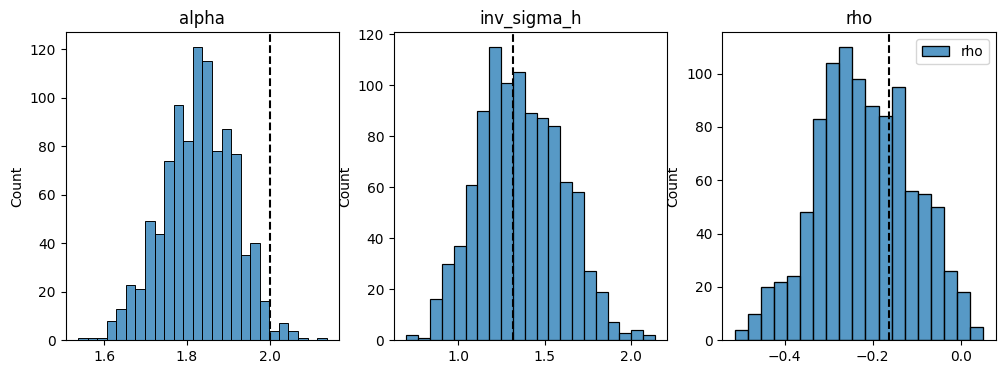

In [15]:
import arviz as az
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for i, v in enumerate(["alpha", "inv_sigma_h", "rho"]):
    sns.histplot(posterior_samples_stacked[v].ravel(), ax=ax[i], label=v)
    ax[i].set_title(v)
    ax[i].axvline(
        true_rho
        if v == "rho"
        else true_inv_sigma_h
        if v == "inv_sigma_h"
        else true_alpha,
        color="k",
        ls="--",
    )
plt.legend()
plt.show()
